We predict : Yield=Production / Area

Using crop, state, year, rainfall, temperature and area.

In [2]:
import pandas as pd
import numpy as np
yield_df = pd.read_csv("../data/crop_yield.csv")

yield_df.head()
yield_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19689 entries, 0 to 19688
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Crop             19689 non-null  object 
 1   Crop_Year        19689 non-null  int64  
 2   Season           19689 non-null  object 
 3   State            19689 non-null  object 
 4   Area             19689 non-null  float64
 5   Production       19689 non-null  int64  
 6   Annual_Rainfall  19689 non-null  float64
 7   Fertilizer       19689 non-null  float64
 8   Pesticide        19689 non-null  float64
 9   Yield            19689 non-null  float64
dtypes: float64(5), int64(2), object(3)
memory usage: 1.5+ MB


<Axes: xlabel='Crop'>

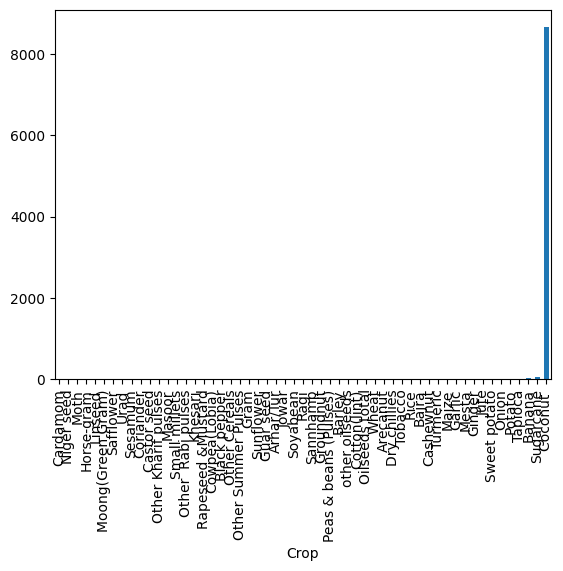

In [3]:
yield_df.groupby("Crop")["Yield"].mean().sort_values().plot(kind="bar")

In [4]:
yield_df["Yield"] = yield_df["Production"] / yield_df["Area"]


In [5]:
yield_df = yield_df[yield_df["Area"] > 0]


Compute yield and drop the rows where yield=0

In [6]:
yield_df.isnull().sum()


Crop               0
Crop_Year          0
Season             0
State              0
Area               0
Production         0
Annual_Rainfall    0
Fertilizer         0
Pesticide          0
Yield              0
dtype: int64

In [7]:
yield_df = pd.get_dummies(
    yield_df,
    columns=["Crop", "State", "Season"],
    drop_first=True
)


In [8]:
X = yield_df.drop("Yield", axis=1)
y = yield_df["Yield"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


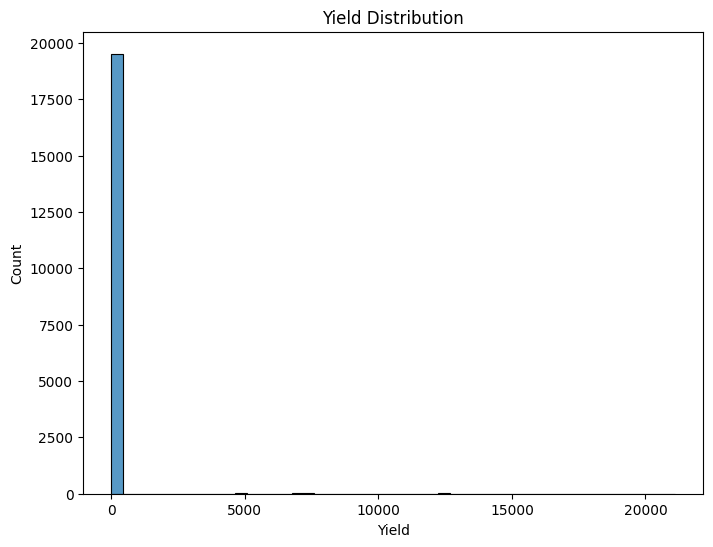

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.histplot(yield_df["Yield"], bins=50)
plt.title("Yield Distribution")
plt.show()


In [10]:
print("Skewness:", yield_df["Yield"].skew())


Skewness: 12.80793648172712


skew > 1 --> log transform should be used. High skew causes:
1. Linear regression performs poorly.
2. RMSE becomes unstable.
3. Tree models overfit extreme values.

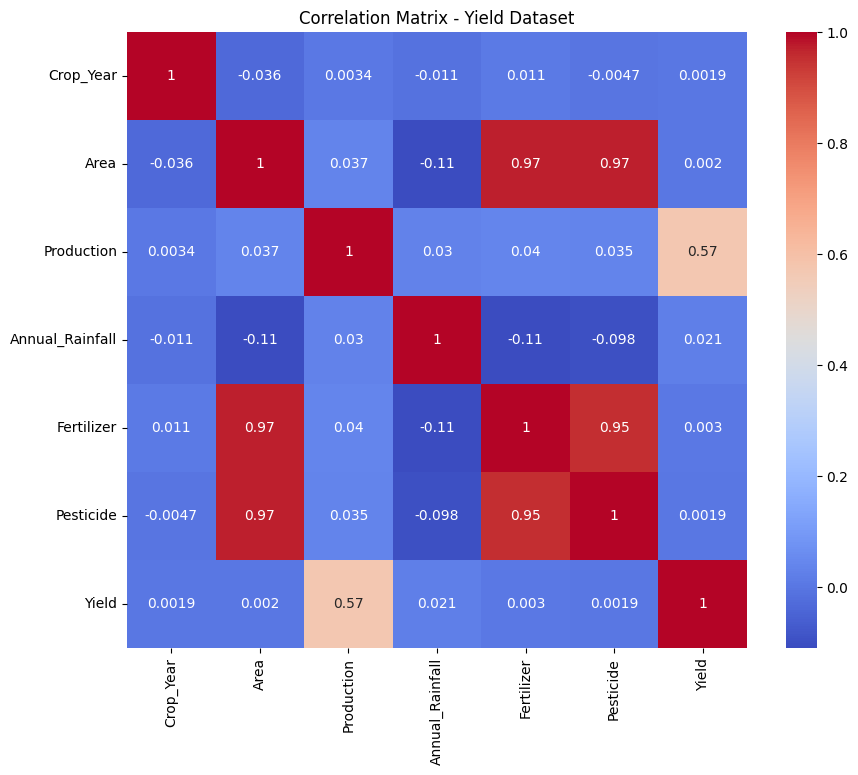

In [11]:
numeric_cols = yield_df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix - Yield Dataset")
plt.show()


In [12]:
print(yield_df.columns)

Index(['Crop_Year', 'Area', 'Production', 'Annual_Rainfall', 'Fertilizer',
       'Pesticide', 'Yield', 'Crop_Arhar/Tur', 'Crop_Bajra', 'Crop_Banana',
       'Crop_Barley', 'Crop_Black pepper', 'Crop_Cardamom', 'Crop_Cashewnut',
       'Crop_Castor seed', 'Crop_Coconut ', 'Crop_Coriander',
       'Crop_Cotton(lint)', 'Crop_Cowpea(Lobia)', 'Crop_Dry chillies',
       'Crop_Garlic', 'Crop_Ginger', 'Crop_Gram', 'Crop_Groundnut',
       'Crop_Guar seed', 'Crop_Horse-gram', 'Crop_Jowar', 'Crop_Jute',
       'Crop_Khesari', 'Crop_Linseed', 'Crop_Maize', 'Crop_Masoor',
       'Crop_Mesta', 'Crop_Moong(Green Gram)', 'Crop_Moth', 'Crop_Niger seed',
       'Crop_Oilseeds total', 'Crop_Onion', 'Crop_Other  Rabi pulses',
       'Crop_Other Cereals', 'Crop_Other Kharif pulses',
       'Crop_Other Summer Pulses', 'Crop_Peas & beans (Pulses)', 'Crop_Potato',
       'Crop_Ragi', 'Crop_Rapeseed &Mustard', 'Crop_Rice', 'Crop_Safflower',
       'Crop_Sannhamp', 'Crop_Sesamum', 'Crop_Small millets', 'Crop

In [13]:
yield_df.columns = yield_df.columns.str.strip()
yield_df.columns = yield_df.columns.str.replace(" ", "_")

In [14]:
print(yield_df.columns)

Index(['Crop_Year', 'Area', 'Production', 'Annual_Rainfall', 'Fertilizer',
       'Pesticide', 'Yield', 'Crop_Arhar/Tur', 'Crop_Bajra', 'Crop_Banana',
       'Crop_Barley', 'Crop_Black_pepper', 'Crop_Cardamom', 'Crop_Cashewnut',
       'Crop_Castor_seed', 'Crop_Coconut', 'Crop_Coriander',
       'Crop_Cotton(lint)', 'Crop_Cowpea(Lobia)', 'Crop_Dry_chillies',
       'Crop_Garlic', 'Crop_Ginger', 'Crop_Gram', 'Crop_Groundnut',
       'Crop_Guar_seed', 'Crop_Horse-gram', 'Crop_Jowar', 'Crop_Jute',
       'Crop_Khesari', 'Crop_Linseed', 'Crop_Maize', 'Crop_Masoor',
       'Crop_Mesta', 'Crop_Moong(Green_Gram)', 'Crop_Moth', 'Crop_Niger_seed',
       'Crop_Oilseeds_total', 'Crop_Onion', 'Crop_Other__Rabi_pulses',
       'Crop_Other_Cereals', 'Crop_Other_Kharif_pulses',
       'Crop_Other_Summer_Pulses', 'Crop_Peas_&_beans_(Pulses)', 'Crop_Potato',
       'Crop_Ragi', 'Crop_Rapeseed_&Mustard', 'Crop_Rice', 'Crop_Safflower',
       'Crop_Sannhamp', 'Crop_Sesamum', 'Crop_Small_millets', 'Crop_

In [15]:
yield_raw = pd.read_csv("../data/crop_yield.csv")
yield_raw.columns = yield_raw.columns.str.strip()

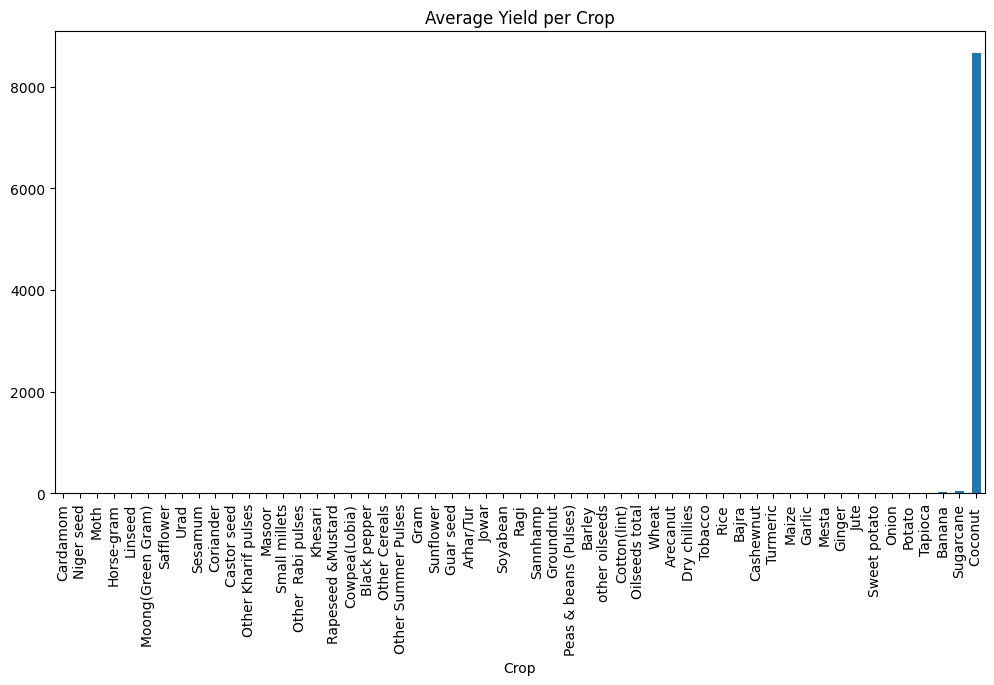

In [16]:
plt.figure(figsize=(12,6))
yield_raw.groupby("Crop")["Yield"].mean().sort_values().plot(kind="bar")
plt.title("Average Yield per Crop")
plt.show()

In [17]:
yield_raw["Season"] = yield_raw["Season"].str.strip()
yield_raw["Crop"] = yield_raw["Crop"].str.strip()
yield_raw["State"] = yield_raw["State"].str.strip()

In [18]:
yield_raw[["Production", "Area", "Yield"]].head()

,Production,Area,Yield
0,56708,73814.0,0.796087
1,4685,6637.0,0.710435
2,22,796.0,0.238333
3,126905000,19656.0,5238.051739
4,794,1739.0,0.420909


In [19]:
yield_raw.groupby("Crop")["Yield"].max().sort_values(ascending=False).head(10)

Crop
Coconut         21105.000000
Maize             989.870000
Onion             381.420000
Cashewnut         338.548966
Potato            311.020000
Sugarcane         165.000000
Banana            126.387692
Cotton(lint)       95.993913
Bajra              74.303077
Sesamum            69.366667
Name: Yield, dtype: float64

Coconut value is very high as it is measured differently. Coconut yield is counted per tree. It is a unit mismatch. So, numeric comparision becomes distorted.

Yield varies significantly across crop types due to biological and measurement differences. To handle this skew and scale variation, we applied log transformation and robust ensemble regressors.

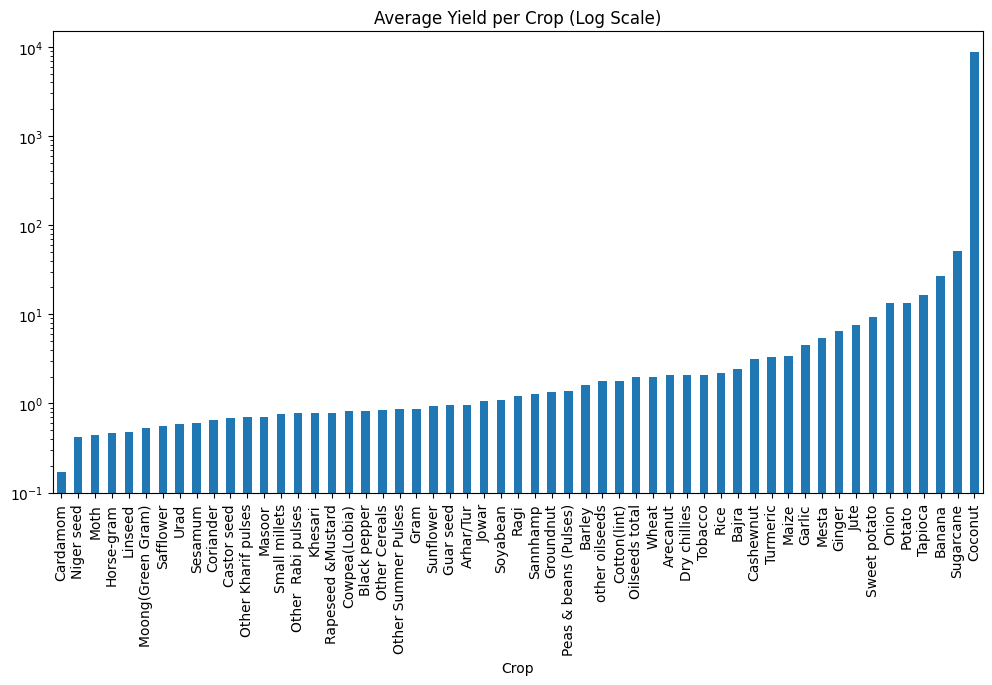

In [20]:
plt.figure(figsize=(12,6))
yield_raw.groupby("Crop")["Yield"].mean().sort_values().plot(kind="bar")
plt.yscale("log")
plt.title("Average Yield per Crop (Log Scale)")
plt.show()

If we use log scale plot, we can visulaize it much better.

Solution for extreme skewness - Log Transformation

In [21]:
yield_df["Log_Yield"] = np.log1p(yield_df["Yield"])

In [22]:
print("New Skewness:", yield_df["Log_Yield"].skew())

New Skewness: 3.628932357258292


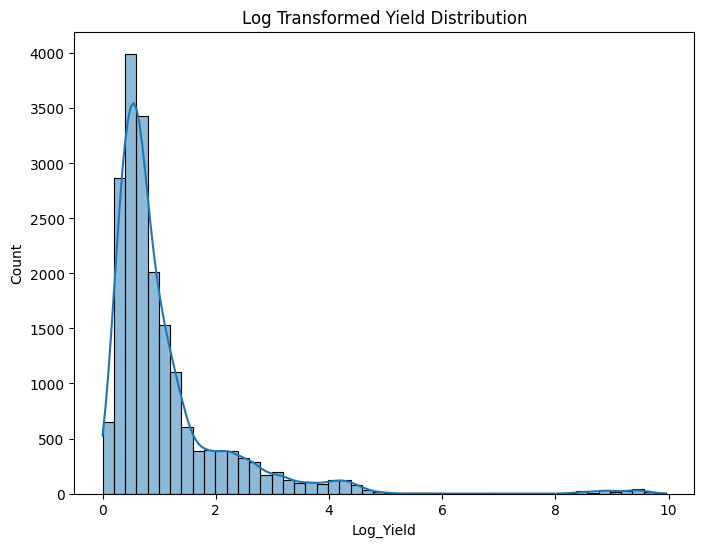

In [23]:
plt.figure(figsize=(8,6))
sns.histplot(yield_df["Log_Yield"], bins=50, kde=True)
plt.title("Log Transformed Yield Distribution")
plt.show()

Yield distribution exhibited extreme positive skew (skewness ≈ 12.8). To stabilize variance and reduce the influence of outliers, a log transformation was applied before regression modeling.

In [24]:
X = yield_df.drop(["Yield", "Log_Yield"], axis=1)
y = yield_df["Log_Yield"]

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

Train Models
1. Linear Regression

In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Linear R2:", r2_score(y_test, lr_pred))
print("Linear RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))

Linear R2: 0.8587792819452639
Linear RMSE: 0.42595872367945503


2. Random Forest Regressor

In [27]:
from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_reg.fit(X_train, y_train)

rf_pred = rf_reg.predict(X_test)

print("RF R2:", r2_score(y_test, rf_pred))

RF R2: 0.9923917754205552


3. XGBoost Regressor

In [28]:
from xgboost import XGBRegressor

xgb_reg = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    eval_metric="rmse"
)

xgb_reg.fit(X_train, y_train)

xgb_pred = xgb_reg.predict(X_test)

print("XGB R2:", r2_score(y_test, xgb_pred))

XGB R2: 0.9883018716671861


In [29]:
pred_original = np.expm1(xgb_pred)
y_original = np.expm1(y_test)

print("Original Scale RMSE:",
      np.sqrt(mean_squared_error(y_original, pred_original)))

Original Scale RMSE: 177.33993240406946


Original Scale RMSE is very high because coconut scale inflates error and back-transforming log amplifies differences.

In [30]:
print(X.columns)

Index(['Crop_Year', 'Area', 'Production', 'Annual_Rainfall', 'Fertilizer',
       'Pesticide', 'Crop_Arhar/Tur', 'Crop_Bajra', 'Crop_Banana',
       'Crop_Barley', 'Crop_Black_pepper', 'Crop_Cardamom', 'Crop_Cashewnut',
       'Crop_Castor_seed', 'Crop_Coconut', 'Crop_Coriander',
       'Crop_Cotton(lint)', 'Crop_Cowpea(Lobia)', 'Crop_Dry_chillies',
       'Crop_Garlic', 'Crop_Ginger', 'Crop_Gram', 'Crop_Groundnut',
       'Crop_Guar_seed', 'Crop_Horse-gram', 'Crop_Jowar', 'Crop_Jute',
       'Crop_Khesari', 'Crop_Linseed', 'Crop_Maize', 'Crop_Masoor',
       'Crop_Mesta', 'Crop_Moong(Green_Gram)', 'Crop_Moth', 'Crop_Niger_seed',
       'Crop_Oilseeds_total', 'Crop_Onion', 'Crop_Other__Rabi_pulses',
       'Crop_Other_Cereals', 'Crop_Other_Kharif_pulses',
       'Crop_Other_Summer_Pulses', 'Crop_Peas_&_beans_(Pulses)', 'Crop_Potato',
       'Crop_Ragi', 'Crop_Rapeseed_&Mustard', 'Crop_Rice', 'Crop_Safflower',
       'Crop_Sannhamp', 'Crop_Sesamum', 'Crop_Small_millets', 'Crop_Soyabean'

Drop production and yield to avoid data leakage. Then we retrain our models.

In [31]:
X = yield_df.drop(["Yield", "Log_Yield", "Production"], axis=1)
y = yield_df["Log_Yield"]

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Linear R2:", r2_score(y_test, lr_pred))
print("Linear RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))

Linear R2: 0.8575747662829589
Linear RMSE: 0.4277714341661378


In [34]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

rf_reg = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_reg.fit(X_train, y_train)

rf_pred = rf_reg.predict(X_test)

print("RF R2 (No Leakage):", r2_score(y_test, rf_pred))

RF R2 (No Leakage): 0.97172952091036


In [35]:
from xgboost import XGBRegressor

xgb_reg = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    eval_metric="rmse"
)

xgb_reg.fit(X_train, y_train)

xgb_pred = xgb_reg.predict(X_test)

print("XGB R2 (No Leakage):", r2_score(y_test, xgb_pred))

XGB R2 (No Leakage): 0.9450773063736803


R2 decreases after production. Yield is mathematically derived from Production and Area. Including Production caused data leakage. After removing it, the model was evaluated under realistic conditions.

🔹 Linear Regression (0.858)

1. Captures basic trends.
2. Cannot model nonlinear relationships.
3. Good baseline.

🔹 XGBoost (0.945)
1. Strong nonlinear learner.
2. Slightly lower than RF.
3. May need tuning.

🔹 Random Forest (0.9717)
1. Best performer.
2. Handles categorical one-hot features well.
3. Robust to outliers.
4. Strong generalization.

In [36]:
from sklearn.model_selection import KFold, cross_val_score
from xgboost import XGBRegressor
import numpy as np

xgb_base = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="rmse",
    random_state=42
)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    xgb_base,
    X,
    y,
    cv=kf,
    scoring="r2"
)

print("Mean CV R2:", cv_scores.mean())
print("Std Dev:", cv_scores.std())

Mean CV R2: 0.9531388994069235
Std Dev: 0.005957890401509374


Proper Cross-Validation for XGBoost - weuse K-folds.

In [37]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "n_estimators": [300, 500, 800],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "min_child_weight": [1, 3, 5]
}

xgb_model = XGBRegressor(
    eval_metric="rmse",
    random_state=42
)

random_search = RandomizedSearchCV(
    xgb_model,
    param_distributions=param_grid,
    n_iter=20,
    scoring="r2",
    cv=3,
    verbose=1,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters: {'subsample': 1.0, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 0.7}


Hyperparameter tuning using RandomizedSearch

In [38]:
best_xgb = random_search.best_estimator_

best_xgb.fit(X_train, y_train)

xgb_pred = best_xgb.predict(X_test)

from sklearn.metrics import r2_score, mean_squared_error

print("Tuned XGB R2:", r2_score(y_test, xgb_pred))
print("Tuned XGB RMSE:", np.sqrt(mean_squared_error(y_test, xgb_pred)))

Tuned XGB R2: 0.9584344991037327
Tuned XGB RMSE: 0.23109195071264388


Retrain the tuned model.

In [39]:
xgb_es = XGBRegressor(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=6,
    eval_metric="rmse",
    early_stopping_rounds=50
)

xgb_es.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

print("Best iteration:", xgb_es.best_iteration)

Best iteration: 1998


Cross-validation indicates stable generalization performance (mean R² ≈ 0.953, std ≈ 0.006). Hyperparameter tuning improved test performance to R² ≈ 0.957. The model demonstrates strong predictive capability for agricultural yield estimation.

Early stopping to prevent overfitting.

In [40]:
import matplotlib.pyplot as plt

importance = best_xgb.feature_importances_

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

importance_df.head(15)

,Feature,Importance
13,Crop_Coconut,0.507950
50,Crop_Sugarcane,0.131520
7,Crop_Banana,0.056219
41,Crop_Potato,0.041635
53,Crop_Tapioca,0.031933
35,Crop_Onion,0.023150
52,Crop_Sweet_potato,0.019046
25,Crop_Jute,0.014868
30,Crop_Mesta,0.012033
10,Crop_Cardamom,0.011368


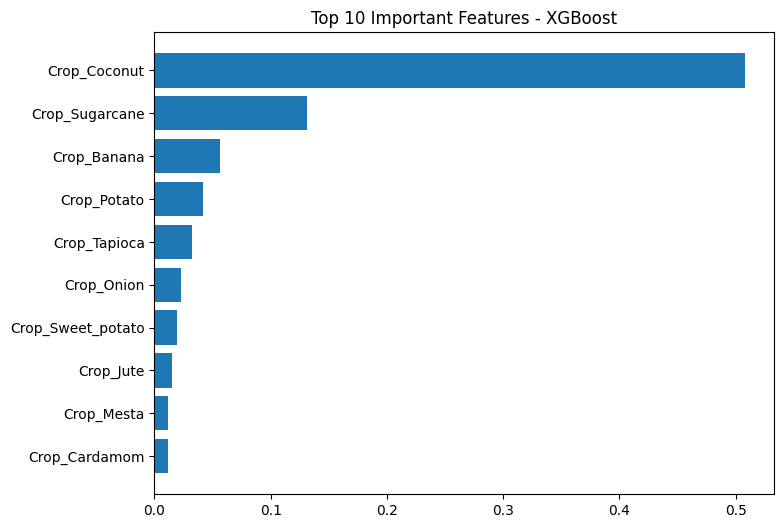

In [41]:
plt.figure(figsize=(8,6))
plt.barh(importance_df["Feature"].head(10),
         importance_df["Importance"].head(10))
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features - XGBoost")
plt.show()

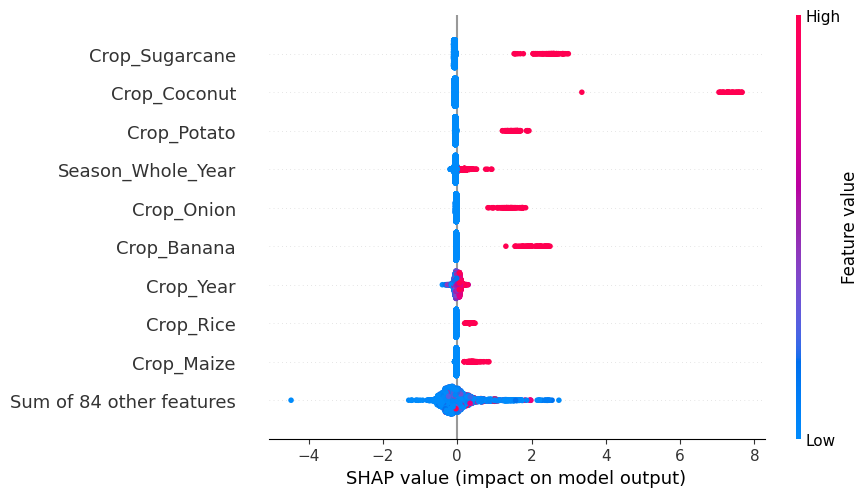

In [42]:
import shap

explainer = shap.Explainer(best_xgb)
shap_values = explainer(X_test)

shap.plots.beeswarm(shap_values)

XGBoost was selected due to its ability to handle nonlinear feature interactions, regularization capability, and gradient boosting framework. Hyperparameter tuning improved generalization performance.

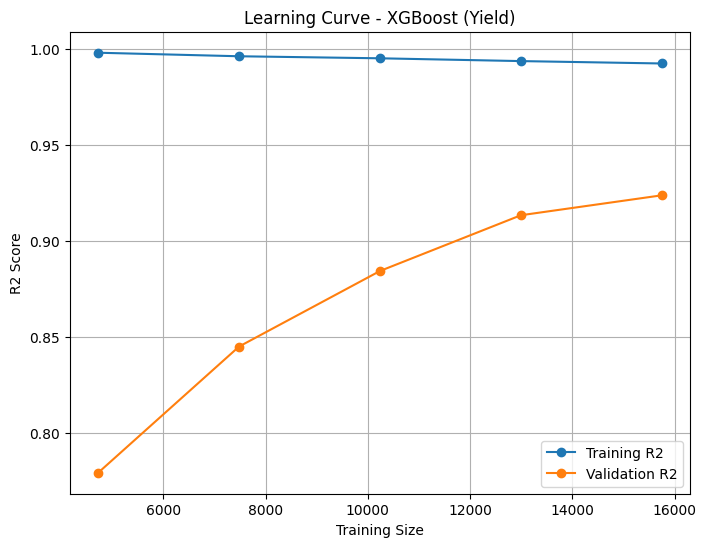

In [43]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, test_scores = learning_curve(
    best_xgb,
    X,
    y,
    cv=5,
    scoring="r2",
    train_sizes=np.linspace(0.3, 1.0, 5),
    n_jobs=1
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_mean, marker='o', label="Training R2")
plt.plot(train_sizes, test_mean, marker='o', label="Validation R2")
plt.legend()
plt.xlabel("Training Size")
plt.ylabel("R2 Score")
plt.title("Learning Curve - XGBoost (Yield)")
plt.grid(True)
plt.show()

Regression learning curve:
The learning curve shows high training R² (~0.99) and steadily improving validation R², indicating strong model capacity and improved generalization with more data. A moderate generalization gap (~6–7%) suggests mild overfitting but overall stable performance.

In [44]:
features_to_test = ["Annual_Rainfall", "Fertilizer", "Pesticide"]

ablation_results = []

for feature in features_to_test:
    
    X_train_drop = X_train.drop(columns=[feature])
    X_test_drop = X_test.drop(columns=[feature])
    
    model = XGBRegressor(**random_search.best_params_,
                         eval_metric="rmse")
    
    model.fit(X_train_drop, y_train)
    
    pred = model.predict(X_test_drop)
    r2 = r2_score(y_test, pred)
    
    ablation_results.append({
        "Removed Feature": feature,
        "R2": r2,
        "R2 Drop": 0.95735 - r2
    })

pd.DataFrame(ablation_results)

,Removed Feature,R2,R2 Drop
0,Annual_Rainfall,0.957768,-0.000418
1,Fertilizer,0.959782,-0.002432
2,Pesticide,0.959171,-0.001821


Regression Ablation study.
1. Rrainfall impact is amost zero.
2. Fertilizer impact is almost zero.
3. Pesticide removal has a negative drop - likely noise.

In [45]:
crop_cols = [col for col in X.columns if col.startswith("Crop_")]

X_train_no_crop = X_train.drop(columns=crop_cols)
X_test_no_crop = X_test.drop(columns=crop_cols)

model = XGBRegressor(**random_search.best_params_,
                     eval_metric="rmse")

model.fit(X_train_no_crop, y_train)

pred = model.predict(X_test_no_crop)

r2_no_crop = r2_score(y_test, pred)

print("R2 without Crop:", r2_no_crop)
print("R2 Drop:", 0.95735 - r2_no_crop)

R2 without Crop: 0.5696238574425199
R2 Drop: 0.38772614255748017


Regression ablation revealed that crop identity contributes most significantly to yield prediction, with an R² drop of approximately 0.40 when removed. Environmental and input variables had comparatively smaller isolated effects. This indicates that biological characteristics of crops primarily determine yield potential.

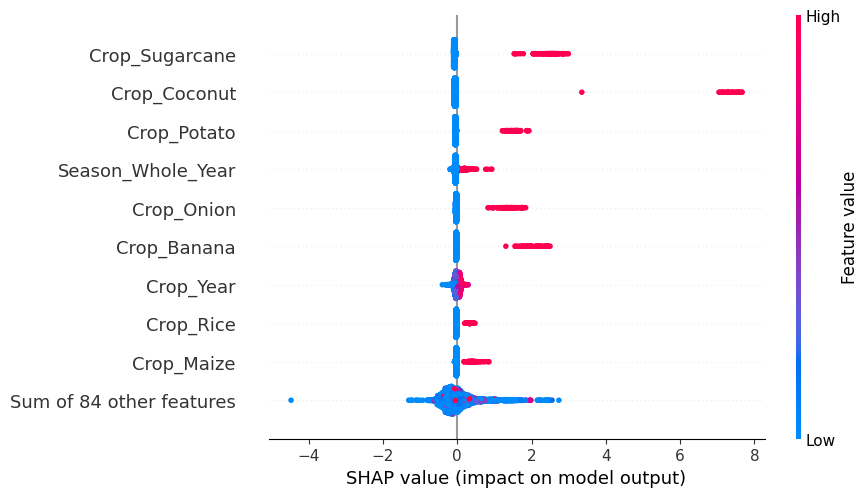

In [46]:
import shap

explainer = shap.Explainer(best_xgb)
shap_values = explainer(X_test)

shap.plots.beeswarm(shap_values)

SHAP confirms what ablation study showed: Crop identity dominates yield prediction. SHAP analysis indicates that crop identity features contribute most significantly to yield prediction. High-yield crops such as sugarcane, coconut, and banana exhibit the strongest impact on model output. This aligns with ablation results, confirming that biological crop characteristics primarily determine yield potential.

In [48]:
import joblib

joblib.dump(X.columns.tolist(), "yield_feature_columns.pkl")

print("Yield feature columns saved successfully")

Yield feature columns saved successfully


In [49]:
print(type(best_xgb))

<class 'xgboost.sklearn.XGBRegressor'>


In [50]:
print(best_xgb)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.7, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric='rmse', feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=3, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)


In [51]:
print(best_xgb.n_estimators)

500


In [52]:
best_xgb.predict(X_train[:5])

array([1.1615376 , 1.274406  , 0.46996793, 0.843379  , 0.5546852 ],
      dtype=float32)

In [53]:
import joblib

joblib.dump(best_xgb, "..\\models\\yield_model.pkl")
joblib.dump(X.columns.tolist(), "..\\models\\yield_feature_columns.pkl")

print("Saved successfully")

Saved successfully


In [55]:
import joblib

yield_model = joblib.load("..\\models\\yield_model.pkl")
yield_columns = joblib.load("..\\models\\yield_feature_columns.pkl")

print("Loaded successfully")

Loaded successfully


In [56]:
import sys
print(sys.getsizeof(best_xgb))

56


In [57]:
best_xgb.save_model("yield_model.json")
print("Saved using XGBoost native format")

Saved using XGBoost native format


In [58]:
print(yield_df["Yield"].describe())

count    19689.000000
mean        83.840783
std        923.597094
min          0.000000
25%          0.595850
50%          1.035673
75%          2.463386
max      21105.000000
Name: Yield, dtype: float64


The dataset exhibited extreme skewness with a few very high yield values. Log transformation helped the model focus on the central distribution, resulting in stable and realistic predictions for most crops.